<a href="https://colab.research.google.com/github/marcewp15/Proyecto-Final-Data-Xperience/blob/main/Proyecto_Final_DataX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proyecto Final - Data Xperience**



Análisis de la Infraestructura de Internet Fijo en Colombia (2023)

Evaluación Estadística y Modelado Predictivo de la Conectividad de Internet Fijo a Nivel Municipal

**1.   Preparación del entorno y carga de datos**


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Lectura del dataset con codificación específica para caracteres latinos
df = pd.read_csv("/content/drive/MyDrive/Internet_Fijo_Accesos.csv",
                 sep=',',
                 encoding='latin-1',
                 engine='python',
                 on_bad_lines='skip')


**2. Limpieza y Transformación de datos**

In [4]:
# Limpieza de comillas y espacios en los nombres de las columnas
df.columns = [col.replace('"', '').strip() for col in df.columns]

In [5]:
# Renombrado de columnas clave para facilitar el análisis
df = df.rename(columns={df.columns[0]: 'AÑO', 'No DE ACCESOS': 'ACCESOS'})

In [6]:
# Eliminación de columnas con códigos geográficos (no necesarios para el análisis)
df = df.drop(columns=['COD_DEPARTAMENTO', 'COD_MUNICIPIO'])

In [7]:
print(f"Total de registros cargados: {len(df)}")


Total de registros cargados: 79553


In [8]:
# Limpieza de caracteres basura en las celdas de texto
for col in df.columns:
    df[col] = df[col].astype(str).str.replace('"', '').str.strip()

In [9]:
# Estandarización de decimales: se cambian comas por puntos para la conversión numérica
df['VELOCIDAD_BAJADA'] = df['VELOCIDAD_BAJADA'].str.replace(',', '.')
df['VELOCIDAD_SUBIDA'] = df['VELOCIDAD_SUBIDA'].str.replace(',', '.')

# Conversión de tipos de datos: De texto (string) a numérico (float/int)
# Se usa errors='coerce' porque a veces traen comas o espacios
df['VELOCIDAD_BAJADA'] = pd.to_numeric(df['VELOCIDAD_BAJADA'], errors='coerce').fillna(0)
df['VELOCIDAD_SUBIDA'] = pd.to_numeric(df['VELOCIDAD_SUBIDA'], errors='coerce').fillna(0)
df['ACCESOS'] = pd.to_numeric(df['ACCESOS'], errors='coerce').fillna(0)


**Modulo 1 - Exploración inicial y manejo de Datos**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79553 entries, 0 to 79552
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AÑO               79553 non-null  object 
 1   TRIMESTRE         79553 non-null  object 
 2   PROVEEDOR         79553 non-null  object 
 3   DEPARTAMENTO      79553 non-null  object 
 4   MUNICIPIO         79553 non-null  object 
 5   SEGMENTO          79553 non-null  object 
 6   TECNOLOGIA        79553 non-null  object 
 7   VELOCIDAD_BAJADA  79553 non-null  float64
 8   VELOCIDAD_SUBIDA  79553 non-null  float64
 9   ACCESOS           79553 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 6.1+ MB


In [11]:
df.head()

,AÑO,TRIMESTRE,PROVEEDOR,DEPARTAMENTO,MUNICIPIO,SEGMENTO,TECNOLOGIA,VELOCIDAD_BAJADA,VELOCIDAD_SUBIDA,ACCESOS
0,2023,2,DIRECTV COLOMBIA LTDA,ATLÃNTICO,PALMAR DE VARELA,RESIDENCIAL - ESTRATO 1,OTRAS TECNOLOGÃAS INALÃMBRICAS,6.0,1.0,3
1,2023,3,DIFUDATOS S A S,CUNDINAMARCA,CUCUNUBÃ,CORPORATIVO,OTRAS TECNOLOGÃAS INALÃMBRICAS,30.0,24.0,1
2,2023,3,COMUNICACION CELULAR S A COMCEL S A,ANTIOQUIA,BARBOSA,RESIDENCIAL - ESTRATO 2,CABLE,30.0,5.0,102
3,2023,2,ACHITEL SAS,BOLÃVAR,ACHÃ,RESIDENCIAL - ESTRATO 1,FIBER TO THE HOME (FTTH),12.0,12.0,3
4,2023,3,COLOMBIA TELECOMUNICACIONES S.A. E.S.P.,VALLE DEL CAUCA,CALI,RESIDENCIAL - ESTRATO 6,FIBER TO THE HOME (FTTH),600.0,256.0,12


In [12]:
df.columns

Index(['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'DEPARTAMENTO', 'MUNICIPIO',
       'SEGMENTO', 'TECNOLOGIA', 'VELOCIDAD_BAJADA', 'VELOCIDAD_SUBIDA',
       'ACCESOS'],
      dtype='object')

In [13]:

df

,AÑO,TRIMESTRE,PROVEEDOR,DEPARTAMENTO,MUNICIPIO,SEGMENTO,TECNOLOGIA,VELOCIDAD_BAJADA,VELOCIDAD_SUBIDA,ACCESOS
0,2023,2,DIRECTV COLOMBIA LTDA,ATLÃNTICO,PALMAR DE VARELA,RESIDENCIAL - ESTRATO 1,OTRAS TECNOLOGÃAS INALÃMBRICAS,6.0,1.0,3
1,2023,3,DIFUDATOS S A S,CUNDINAMARCA,CUCUNUBÃ,CORPORATIVO,OTRAS TECNOLOGÃAS INALÃMBRICAS,30.0,24.0,1
2,2023,3,COMUNICACION CELULAR S A COMCEL S A,ANTIOQUIA,BARBOSA,RESIDENCIAL - ESTRATO 2,CABLE,30.0,5.0,102
3,2023,2,ACHITEL SAS,BOLÃVAR,ACHÃ,RESIDENCIAL - ESTRATO 1,FIBER TO THE HOME (FTTH),12.0,12.0,3
4,2023,3,COLOMBIA TELECOMUNICACIONES S.A. E.S.P.,VALLE DEL CAUCA,CALI,RESIDENCIAL - ESTRATO 6,FIBER TO THE HOME (FTTH),600.0,256.0,12
...,...,...,...,...,...,...,...,...,...,...
79548,2023,1,CONECTTIC S A S,HUILA,OPORAPA,RESIDENCIAL - ESTRATO 2,FIBER TO THE HOME (FTTH),10.0,5.0,20
79549,2023,3,COMUNICACION CELULAR S A COMCEL S A,CAQUETA,FLORENCIA,RESIDENCIAL - ESTRATO 1,CABLE,5.0,2.0,1
79550,2023,3,CABLEMAS S.A.S,CÃRDOBA,MONTERÃA,RESIDENCIAL - ESTRATO 3,FIBER TO THE HOME (FTTH),300.0,300.0,5
79551,2023,1,COLOMBIA TELECOMUNICACIONES S.A. E.S.P.,ANTIOQUIA,MEDELLÃN,RESIDENCIAL - ESTRATO 5,FIBER TO THE HOME (FTTH),204.0,204.0,8


In [14]:
# Detección y tratamiento de valores nulos generados tras la conversión numérica
print("Valores nulos detectados:")
print(df.isnull().sum())

df['VELOCIDAD_BAJADA'] = df['VELOCIDAD_BAJADA'].fillna(0)
df['VELOCIDAD_SUBIDA'] = df['VELOCIDAD_SUBIDA'].fillna(0)

# Verificar el cambio
df.info()

Valores nulos detectados:
AÑO                 0
TRIMESTRE           0
PROVEEDOR           0
DEPARTAMENTO        0
MUNICIPIO           0
SEGMENTO            0
TECNOLOGIA          0
VELOCIDAD_BAJADA    0
VELOCIDAD_SUBIDA    0
ACCESOS             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79553 entries, 0 to 79552
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AÑO               79553 non-null  object 
 1   TRIMESTRE         79553 non-null  object 
 2   PROVEEDOR         79553 non-null  object 
 3   DEPARTAMENTO      79553 non-null  object 
 4   MUNICIPIO         79553 non-null  object 
 5   SEGMENTO          79553 non-null  object 
 6   TECNOLOGIA        79553 non-null  object 
 7   VELOCIDAD_BAJADA  79553 non-null  float64
 8   VELOCIDAD_SUBIDA  79553 non-null  float64
 9   ACCESOS           79553 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 6.1+ MB


In [15]:
# Resumen de accesos agrupados por tecnología
resumen = df.groupby('TECNOLOGIA')['ACCESOS'].sum().sort_values(ascending=False)
print(resumen)

TECNOLOGIA
CABLE                                                   1346974
FIBER TO THE HOME (FTTH)                                1098956
HYBRID FIBER COAXIAL (HFC)                               705199
XDSL                                                     229290
OTRAS TECNOLOGÃAS INALÃMBRICAS                          77925
WIFI                                                      47846
FIBER TO THE CABINET (FTTC)                               36428
OTRAS TECNOLOGÃAS DE FIBRA (ANTES FTTX)                  13282
SATELITAL                                                 10964
WIMAX                                                      5660
OTRAS TECNOLOGÃAS FIJAS                                   3600
FIBER TO THE PREMISES                                      2518
FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)       2036
FIBER TO THE NODE (FTTN)                                   1703
NA (NO APLICA)                                              743
FIBER TO THE ANTENNA (FTTA)  

**Visualización de Datos (Análisis Gráfico)**

/tmp/ipykernel_245/634352669.py:9: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_245/634352669.py:9: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


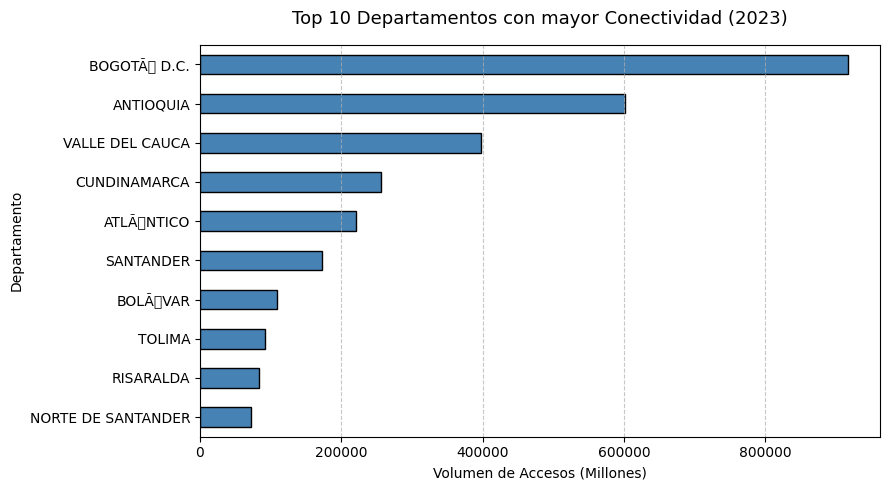

In [16]:
# Gráfico 1: Top 10 de Departamentos con Mayor Conectividad
analisis_depto = df.groupby('DEPARTAMENTO')['ACCESOS'].sum().sort_values(ascending=True).tail(10)
plt.figure(figsize=(9, 5))
analisis_depto.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Departamentos con mayor Conectividad (2023)', fontsize=13, pad=15)
plt.xlabel('Volumen de Accesos (Millones)', fontsize=10)
plt.ylabel('Departamento', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



--- DISTRIBUCIÓN POR SEGMENTO ---
SEGMENTO
RESIDENCIAL - ESTRATO 2            1298762
RESIDENCIAL - ESTRATO 3             980536
RESIDENCIAL - ESTRATO 1             394019
RESIDENCIAL - ESTRATO 4             367147
CORPORATIVO                         276104
RESIDENCIAL - ESTRATO 5             112893
SIN ESTRATIFICAR                     84363
RESIDENCIAL - ESTRATO 6              67738
USO PROPIO INTERNO DEL OPERADOR       1766
Name: ACCESOS, dtype: int64


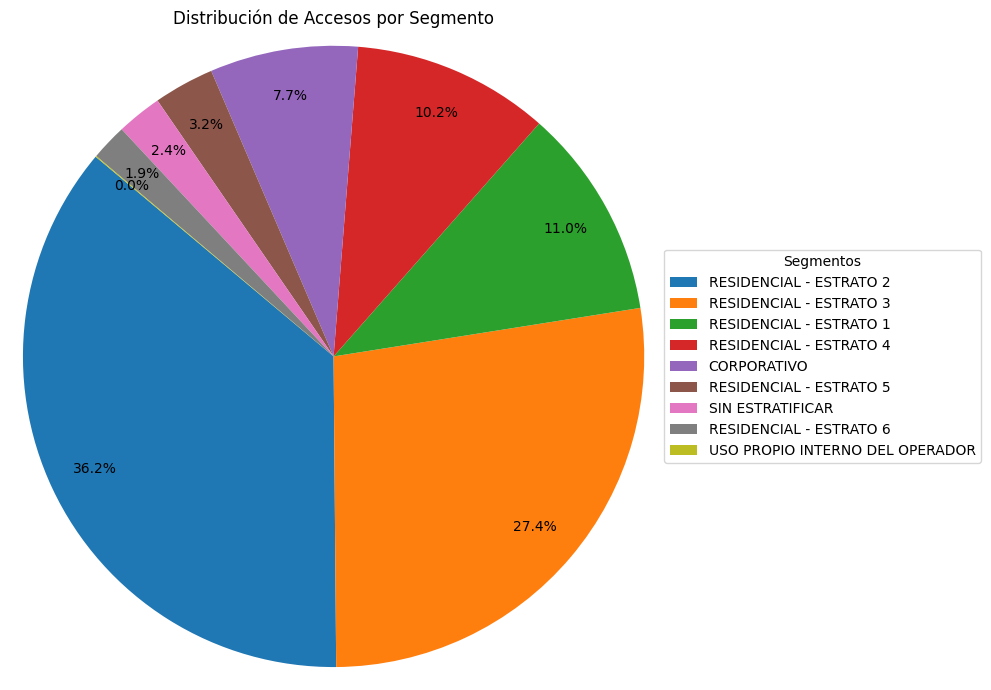

In [17]:
# Gráfico 2: Distribución por Segmento (Empresas vs Hogares)
analisis_segmento = df.groupby('SEGMENTO')['ACCESOS'].sum().sort_values(ascending=False)

print("\n--- DISTRIBUCIÓN POR SEGMENTO ---")
print(analisis_segmento)

plt.figure(figsize=(12, 7))
analisis_segmento.plot(kind='pie', autopct='%1.1f%%', labels=None, pctdistance=0.85, startangle=140, radius=1.2)
plt.legend(labels=analisis_segmento.index, title="Segmentos", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Distribución de Accesos por Segmento')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Modulo 2 - Análisis Estadístico**

In [18]:
# Tendencia Central
print("--- Medidas de Tendencia Central ---")
print(f"Media de Velocidad de Bajada: {df['VELOCIDAD_BAJADA'].mean():.2f} Mbps")
print(f"Mediana de Velocidad de Bajada: {df['VELOCIDAD_BAJADA'].median():.2f} Mbps")
print(f"Moda de Tecnología: {df['TECNOLOGIA'].mode()[0]}")

# Dispersión
print("\n--- Medidas de Dispersión ---")
print(f"Desviación Estándar de Velocidad: {df['VELOCIDAD_BAJADA'].std():.2f}")
print(f"Varianza de Accesos: {df['ACCESOS'].var():.2f}")
print(f"Rango de Velocidad: {df['VELOCIDAD_BAJADA'].max() - df['VELOCIDAD_BAJADA'].min()} Mbps")

# Resumen estadístico completo
resumen_estadistico = df[['VELOCIDAD_BAJADA', 'VELOCIDAD_SUBIDA', 'ACCESOS']].describe()
print("\nResumen para el informe:")
print(resumen_estadistico)


--- Medidas de Tendencia Central ---
Media de Velocidad de Bajada: 354.86 Mbps
Mediana de Velocidad de Bajada: 50.00 Mbps
Moda de Tecnología: CABLE

--- Medidas de Dispersión ---
Desviación Estándar de Velocidad: 6873.74
Varianza de Accesos: 277747.90
Rango de Velocidad: 1000000.0 Mbps

Resumen para el informe:
       VELOCIDAD_BAJADA  VELOCIDAD_SUBIDA       ACCESOS
count      79553.000000      79553.000000  79553.000000
mean         354.863637        289.480277     45.043279
std         6873.739748       6857.064954    527.017929
min            0.000000          0.000000      0.000000
25%           10.000000          4.000000      1.000000
50%           50.000000         10.000000      3.000000
75%          200.000000         42.500000     12.000000
max      1000000.000000    1000000.000000  70742.000000


**Modulo 3 - Machine Learning (Regresión y Clasificación)**

In [19]:
from sklearn.linear_model import LinearRegression

# Regresión Lineal: Predicción de Accesos según Velocidad
# Filtramos Outliers para mejorar la precisón (velocidades < 1000 Mbps)
df_modelo = df[(df['VELOCIDAD_BAJADA'] > 0) & (df['VELOCIDAD_BAJADA'] <= 1000)].copy()

# Definición de variables con los datos filtrados
X = df_modelo[['VELOCIDAD_BAJADA']].values
y = df_modelo['ACCESOS'].values

modelo_final = LinearRegression().fit(X, y)

# Resultados
r_cuadrado = modelo_final.score(X, y)
pendiente = modelo_final.coef_[0]

print("--- MÓDULO 3: MACHINE LEARNING (DATOS NORMALIZADOS) ---")
print(f"Precisión del Modelo (R^2): {r_cuadrado:.4f}")
print(f"Interpretación: Por cada 1 Mbps extra, los accesos cambian en {pendiente:.4f}")


--- MÓDULO 3: MACHINE LEARNING (DATOS NORMALIZADOS) ---
Precisión del Modelo (R^2): 0.0006
Interpretación: Por cada 1 Mbps extra, los accesos cambian en 0.0766


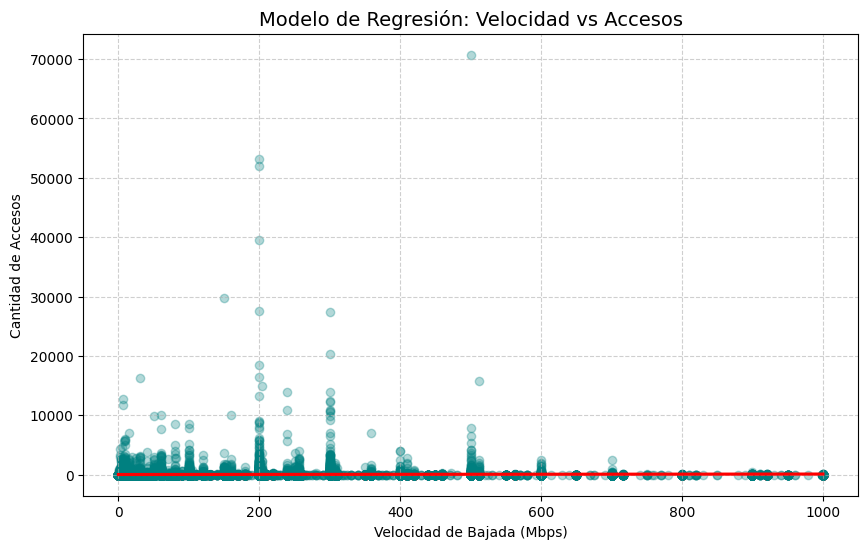

In [20]:
import seaborn as sns

# Visualización del gráfico de dispersión con la línea de tendencia
plt.figure(figsize=(10, 6))
sns.regplot(x='VELOCIDAD_BAJADA', y='ACCESOS', data=df_modelo,
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Modelo de Regresión: Velocidad vs Accesos', fontsize=14)
plt.xlabel('Velocidad de Bajada (Mbps)')
plt.ylabel('Cantidad de Accesos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<Figure size 800x600 with 0 Axes>

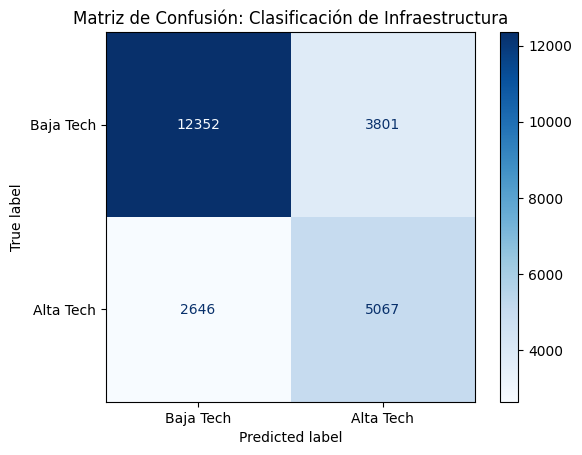

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Clasificación: Infraestructura Legada vs Alta Tecnología, se definen las clases para la clasificación
# 1 = Alta Tecnología (Fibra/Cable), 0 = Tecnología Legada (Cobre/Otras)
tecnologias_altas = ['FIBRA ÓPTICA', 'CABLE', 'FTTH', 'HFC']
df['CLASE_TECH'] = df['TECNOLOGIA'].apply(lambda x: 1 if str(x).upper() in tecnologias_altas else 0)

X = df[['VELOCIDAD_BAJADA', 'ACCESOS']]
y = df['CLASE_TECH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clasificador = RandomForestClassifier(n_estimators=10, max_depth=5).fit(X_train, y_train)

# Matriz de Confusion para validar el modelo de clasificación
y_pred = clasificador.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baja Tech', 'Alta Tech'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión: Clasificación de Infraestructura')
plt.show()


In [22]:
# Exportación de los resultados
df.to_csv('proyecto_final_entregable_2023.csv', index=False)